# The Fourth Circle: Neural Networks, Part Four 
## Transformers III: Vision Transformer

<br/>
Jiří Fejlek

2026-04-30
<br/>

In the previous project, we introduced the transformer architecture [[1](#1)] and demonstrated its primary natural application: sequence-to-sequence natural language processing tasks. However, the application of transformers is much more varied, including computer vision [[2](#2)]. We have already discussed neural networks for image processing in great detail. The field was, until the development of transformers, dominated by convolutional neural networks (CNNs), and it was CNNs that delivered the first major success story for the applicability of neural networks in general. With vision transformers, this dominance was disrupted. 

## Table of Contents

- [Vision Transformer](#vision_trans)
    - [Patch Embedding](#patch_emb)
    - [Implementation](#impl)
    - [Training Vision Transformer on Fashion-MNIST and CIFAR-10](#training)
- [Transfer Learning](#transfer_learning)
- [References](#references)

## Vision Transformer <a class="anchor" id="vision_trans"></a>

Before we look at vision transformers,  we will include the usual initial parts of the code.

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import math

import torchvision
import torch

from torch import nn
from torch.utils.data import DataLoader
import torch.nn.functional as F

import re
import collections
import os

np.set_printoptions(legacy='1.25')

In [2]:
cuda_device = torch.device('cuda')
torch.cuda.get_device_name(cuda_device)

'NVIDIA GeForce RTX 4070 Ti'

For this project, we will use Fashion-MNIST [[3](#3)] and CIFAR-10 (https://www.cs.toronto.edu/~kriz/cifar.html). Let us remind ourselves that we can load the Fashion-MNIST dataset (and analogously CIFAR-10) as follows.

In [3]:
torch.manual_seed(123)

transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [28, 28], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = True) 

We also included standard image augmentation during training (random horizontal flipping and random cropping).

### Patch Embedding <a class="anchor" id="patch_emb"></a>

The vision transformer is first and foremost a transformer, and hence its architecture is, by and large, identical to the original transformer architecture.

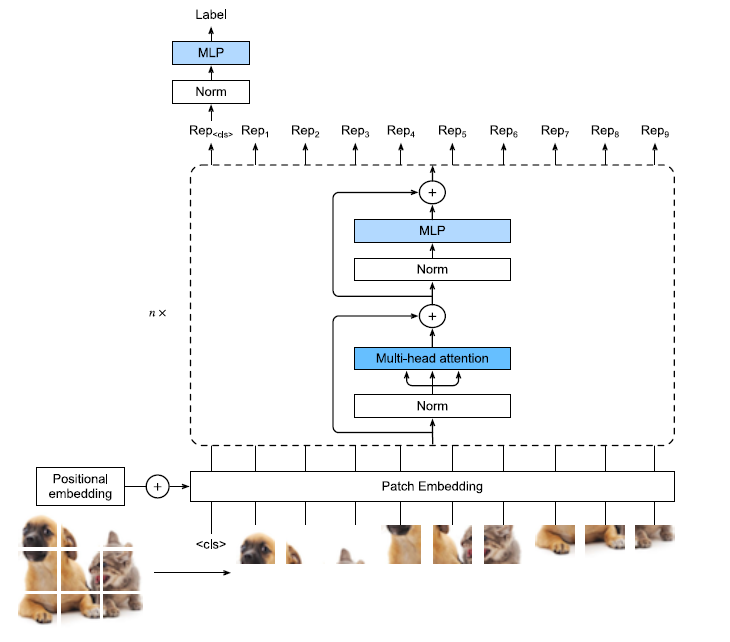

Of course, the input into the transformer is the main difference: instead of a sequence of words, we now have a sequence of pixels.
We could use pixels themselves as the tokens, but then the figures would be represented as very long sequences. Thence, the vision transformer splits the figure into flattened *patches*, which will play the role of the token embeddings for the model.

To perform the so-called *patch embedding* [[1](#1)], we will use the implementation from [[4](#4)]. Notice that we simplify the computation of flattened patches by using a convolution.

In [4]:
class PatchEmbedding(nn.Module):
    
    def __init__(self, img_size, patch_size, num_hiddens):
        
        super().__init__()
        
        def _make_tuple(x):
            if not isinstance(x, (list, tuple)):
                return (x, x)
            return x
            
        img_size, patch_size = _make_tuple(img_size), _make_tuple(patch_size)
        self.num_patches = (img_size[0] // patch_size[0]) * (img_size[1] // patch_size[1])
        self.conv = nn.LazyConv2d(num_hiddens, kernel_size = patch_size, stride = patch_size)
        
    def forward(self, X):
        # Output shape: (batch size, no. of patches, no. of channels)
        return self.conv(X).flatten(2).transpose(1, 2)

Let us test the patch embeddings on the batch of figures from Fashion-MNIST. We will use 2x2 patches, and thus, the embedding is $28/2 \times 28/2 = 196$ long (in general, it is $cp^2$, where $p$ is the dimension of the patch and $c$ is the number of channels of the image).

In [5]:
img_size = 28
patch_size = 2
num_hiddens = 256

patch_emb = PatchEmbedding(img_size, patch_size, num_hiddens)

In [6]:
for batch, (X, y) in enumerate(fashion_mnist_train_loader):
    break

In [7]:
X.size()

torch.Size([250, 1, 28, 28])

In [8]:
patch_emb = PatchEmbedding(img_size, patch_size, num_hiddens)

In [9]:
patch_emb(X).size()

torch.Size([250, 196, 256])

In [10]:
patch_emb.num_patches

196

### Implementation <a class="anchor" id="impl"></a>

Let us go through the implementation of the vision transformer from [[4](#4)]. The multilayer perceptron (MLP) block in the vision trasnformer is is slightly different from the positionwise FFN; it uses the GELU activation function ($\text{GELU}(x) = x \Phi(x)$, where $\Phi$ is the cumulative distribution function of the normal distribution). 

In [11]:
class ViTMLP(nn.Module):
    
    def __init__(self, mlp_num_hiddens, mlp_num_outputs, dropout = 0.5):
        super().__init__()
        
        self.dense1 = nn.LazyLinear(mlp_num_hiddens)
        self.gelu = nn.GELU()
        self.dropout1 = nn.Dropout(dropout)
        self.dense2 = nn.LazyLinear(mlp_num_outputs)
        self.dropout2 = nn.Dropout(dropout)
        
    def forward(self, x):
        return self.dropout2(self.dense2(self.dropout1(self.gelu(self.dense1(x)))))

Another slight modification is that the encoder block uses layer normalization before the multi-head attention and the MLP block. The last slight change is using learnable positional encoding instead of a fixed one. 

In [12]:
class DotProductAttention(nn.Module):
    
    def __init__(self, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, queries, keys, values, valid_lens = None):
        
        d = queries.shape[-1]
         
        # Queries: (batch_size, number of queries, q_d)
        # Keys: (batch_size, number of keys = number of values, k_d)
        # Values: (batch_size, number of keys = number of values, v_d)
        # Valid_lens: (batch_size) or (batch_size, number of queries)
        
        scores = torch.bmm(queries, keys.transpose(1, 2)) / math.sqrt(d)
        self.attention_weights = masked_softmax(scores, valid_lens)

        return torch.bmm(self.dropout(self.attention_weights), values)

In [13]:
def masked_softmax(X, valid_lens): 
    
    def _sequence_mask(X, valid_len, value = 0):
        maxlen = X.size(1)
        mask = torch.arange((maxlen), dtype = torch.float32, device = X.device)[None, :] < valid_len[:, None]
        X[~mask] = value
        return X
        
    if valid_lens is None:
        return nn.functional.softmax(X, dim = -1)
    else:
        shape = X.shape
        
        if valid_lens.dim() == 1:
            valid_lens = torch.repeat_interleave(valid_lens, shape[1])
        else:
            valid_lens = valid_lens.reshape(-1)

        X = _sequence_mask(X.reshape(-1, shape[-1]), valid_lens, value=-1e6)
        return nn.functional.softmax(X.reshape(shape), dim=-1)

In [14]:
class MultiHeadAttention(nn.Module): 

    def transpose_qkv(self, X):
        
        X = X.reshape(X.shape[0], X.shape[1], self.num_heads, -1)
        X = X.permute(0, 2, 1, 3)
        return X.reshape(-1, X.shape[2], X.shape[3])
        
    def transpose_output(self, X):
        
        X = X.reshape(-1, self.num_heads, X.shape[1], X.shape[2])
        X = X.permute(0, 2, 1, 3)
        return X.reshape(X.shape[0], X.shape[1], -1)
        
    def __init__(self, attention_size, num_heads, dropout, bias = False):
        
        super().__init__()
        self.num_heads = num_heads
        self.attention = DotProductAttention(dropout)
        self.W_q = nn.LazyLinear(attention_size, bias = bias)
        self.W_k = nn.LazyLinear(attention_size, bias = bias)
        self.W_v = nn.LazyLinear(attention_size, bias = bias)
        self.W_o = nn.LazyLinear(attention_size, bias = bias)
        
    def forward(self, queries, keys, values, valid_lens):
        
        queries = self.transpose_qkv(self.W_q(queries))
        keys = self.transpose_qkv(self.W_k(keys))
        values = self.transpose_qkv(self.W_v(values))
        
        if valid_lens is not None:
            valid_lens = torch.repeat_interleave(valid_lens, repeats=self.num_heads, dim=0)
            
        output = self.attention(queries, keys, values, valid_lens)
        output_concat = self.transpose_output(output)
            
        return self.W_o(output_concat)

In [15]:
class ViTBlock(nn.Module):
    
    def __init__(self, num_hiddens, norm_shape, mlp_num_hiddens, num_heads, dropout, use_bias = False):
        super().__init__()
        
        self.ln1 = nn.LayerNorm(norm_shape)
        self.attention = MultiHeadAttention(num_hiddens, num_heads, dropout, use_bias)
        self.ln2 = nn.LayerNorm(norm_shape)
        self.mlp = ViTMLP(mlp_num_hiddens, num_hiddens, dropout)
        
    def forward(self, X, valid_lens=None):
        X = X + self.attention(*([self.ln1(X)] * 3), valid_lens)
        return X + self.mlp(self.ln2(X))

Overall, we get the following vision transformer [[4](#4)].

In [16]:
class ViT(nn.Module):
    
    def __init__(self, img_size, patch_size, num_hiddens, mlp_num_hiddens, num_heads, num_blks, emb_dropout, blk_dropout, num_classes, use_bias = False):
        super().__init__()
        
        self.patch_embedding = PatchEmbedding(img_size, patch_size, num_hiddens)

        # <cls> embedding
        self.cls_token = nn.Parameter(torch.zeros(1, 1, num_hiddens))
        num_steps = self.patch_embedding.num_patches + 1 
        
        # learnable positional embeddings 
        self.pos_embedding = nn.Parameter(torch.randn(1, num_steps, num_hiddens))
        
        self.dropout = nn.Dropout(emb_dropout)
        
        self.blks = nn.Sequential()
        for i in range(num_blks):
            self.blks.add_module(f"{i}", ViTBlock(num_hiddens, num_hiddens, mlp_num_hiddens, num_heads, blk_dropout, use_bias))
        
        self.head = nn.Sequential(nn.LayerNorm(num_hiddens), nn.Linear(num_hiddens, num_classes))
        
        
    def forward(self, X):
        
        X = self.patch_embedding(X)
        X = torch.cat((self.cls_token.expand(X.shape[0], -1, -1), X), 1)
        X = self.dropout(X + self.pos_embedding)
        
        for blk in self.blks:
            X = blk(X)
        return self.head(X[:, 0])

We can notice that the implementation adds a special \<cls\> (classification) token to the patches. This \<cls\> token represents the entire image, and it is the output of the last transformer block corresponding to the \<cls\> token, which is used for classification via the block *ViT.head* (layer normalization + linear layer). The authors of [[2](#2)] state that they used the \<cls\> token to remain consistent with transformer models (for example,  see the BERT language model). They also tested classification directly from patch embeddings using average pooling and a linear layer (as in CNNs), and performance was similar (interestingly, both approaches require different learning rates to obtain the same results) [[2](#2)].

### Training Vision Transformer on Fashion-MNIST and CIFAR-10 <a class="anchor" id="training"></a>

We begin by evaluating our model on Fashion-MNIST.

In [17]:
def train_test_loop_cuda(train_data_loader, test_data_loader, model, loss_fn, optimizer, scheduler):
    
    softmax = torch.nn.Softmax(dim = 1)
    model.train()

    loss_sum_train  = 0
    accu_sum_train = 0
    size_train = 0

    
    for batch, (X, y) in enumerate(train_data_loader):

        X = X.to(cuda_device)
        y = y.to(cuda_device)

        optimizer.zero_grad() # zero out the gradients
        
        pred_logits = model(X) # forward pass
        loss = loss_fn(pred_logits, y) # loss evaluation 

        # Backpropagation
        loss.backward() # gradient evaluation
        optimizer.step() # SGD step
        

        # compute prediction epoch loss and accuracy
        with torch.no_grad(): # we do not need to compute the gradients
            loss_sum_train = loss_sum_train + loss*len(X)
            size_train = size_train + len(X)
            accu_sum_train = accu_sum_train + ((softmax(pred_logits).argmax(dim = 1)-y).abs() == 0).long().sum()

    # evaluate performance on the test set
    with torch.no_grad(): 
        
        loss_sum_train = loss_sum_train/size_train
        accu_sum_train = accu_sum_train/size_train
        
        model.eval() 
        loss_sum_test  = 0
        accu_sum_test = 0
        size_test = 0
        
        for batch, (X_test, y_test) in enumerate(test_data_loader):

            X_test = X_test.to(cuda_device)
            y_test = y_test.to(cuda_device)
            
            pred_logits_test = model(X_test)
            loss_sum_test = loss_sum_test + loss_fn(pred_logits_test, y_test)*len(X_test)
            accu_sum_test = accu_sum_test + ((softmax(pred_logits_test).argmax(dim = 1)-y_test).abs() == 0).long().sum()
            size_test = size_test + len(X_test)

        loss_sum_test = loss_sum_test/size_test
        accu_sum_test = accu_sum_test/size_test
        
    # learning rate step; we use loss_sum_train for ReduceLROnPlateau
    learning_rate = scheduler.get_last_lr() 
    scheduler.step() 
    
    return  loss_sum_train.detach(), loss_sum_test.detach(), learning_rate[0], accu_sum_train.detach(), accu_sum_test.detach()

In [18]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [28, 28], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False)  


img_size = 28
patch_size = 4
num_hiddens = 512
mlp_num_hiddens = 512*4
num_heads = 8
num_blks = 2

emb_dropout = 0.1
blk_dropout = 0.1


vit_cuda = ViT(img_size = img_size, patch_size = patch_size, num_hiddens = num_hiddens, 
               mlp_num_hiddens = mlp_num_hiddens, num_heads = num_heads, num_blks = num_blks, 
               emb_dropout = emb_dropout, blk_dropout = blk_dropout, num_classes = 10).to(cuda_device)

We can check the forward pass of our model and the number of parameters.

In [19]:
for batch, (X, y) in enumerate(fashion_mnist_train_loader):
    break
    
vit_cuda(X.to(cuda_device))

tensor([[-0.3164,  0.8641,  0.6801,  ...,  0.3912, -0.2653, -0.3928],
        [-0.0307,  1.3015,  0.4825,  ...,  0.5373, -0.3130, -0.1992],
        [-0.2705,  1.1293,  0.7704,  ...,  0.6681, -0.3055, -0.5042],
        ...,
        [-0.1897,  1.1661,  0.6954,  ...,  0.3824, -0.0558, -0.2972],
        [-0.6448,  0.8750,  0.6784,  ...,  0.2214, -0.4993, -0.1473],
        [-0.1775,  0.9321,  0.3913,  ...,  0.5309, -0.1875, -0.4085]],
       device='cuda:0', grad_fn=<AddmmBackward0>)

In [20]:
sum(p.numel() for p in vit_cuda.parameters() if p.requires_grad)

6341642

Let us train the model.

In [21]:
optim_SGD_cuda =  torch.optim.SGD(vit_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.0001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[75], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 100

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, vit_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

2834.651944875717


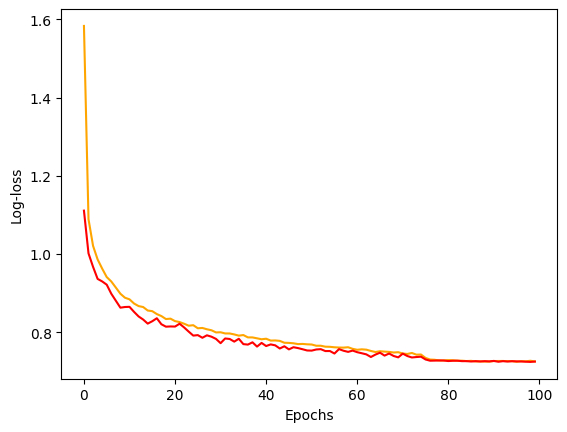

In [22]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

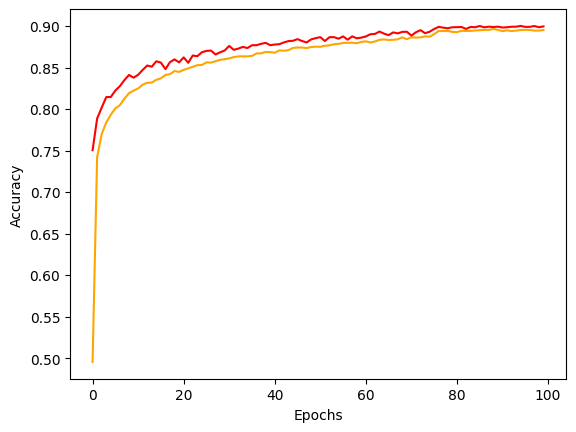

In [23]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

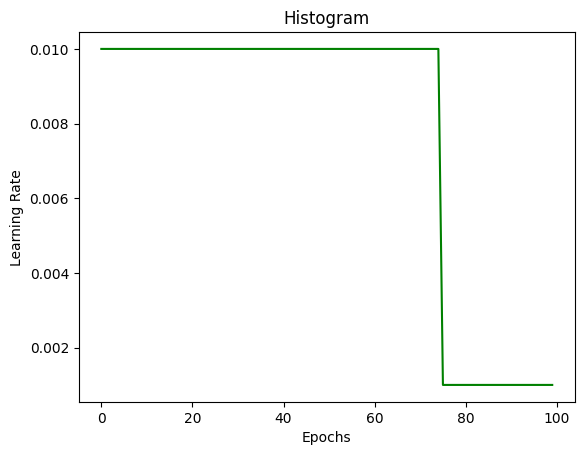

In [24]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [26]:
accu_epochs_train[99]

0.8951333165168762

In [27]:
accu_epochs_test[99]

0.8994999527931213

In [28]:
accu_epochs_test.max()

0.9000999927520752

We reached about 90% test-set accuracy, which is not particularly impressive compared to CNNs. Let us test the CIFAR-10 next.

In [30]:
torch.manual_seed(123)

transforms_cifar10_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size=[32,32], scale = [0.8, 1.4]),
    ]
)

transforms_cifar10_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])]
)

cifar10_train = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_cifar10_train)
cifar10_test = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_cifar10_test)


cifar10_train_loader = DataLoader(dataset = cifar10_train, batch_size = 250, shuffle = True) 
cifar10_test_loader = DataLoader(dataset = cifar10_test, batch_size = 250, shuffle = False)


img_size = 32
patch_size = 4
num_hiddens = 512
mlp_num_hiddens = 512*4
num_heads = 8
num_blks = 2

emb_dropout = 0.1
blk_dropout = 0.1


vit_cuda = ViT(img_size = img_size, patch_size = patch_size, num_hiddens = num_hiddens, 
               mlp_num_hiddens = mlp_num_hiddens, num_heads = num_heads, num_blks = num_blks, 
               emb_dropout = emb_dropout, blk_dropout = blk_dropout, num_classes = 10).to(cuda_device)


optim_SGD_cuda =  torch.optim.SGD(vit_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.0001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[75], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 100

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(cifar10_train_loader, cifar10_test_loader, vit_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

2623.1323499679565


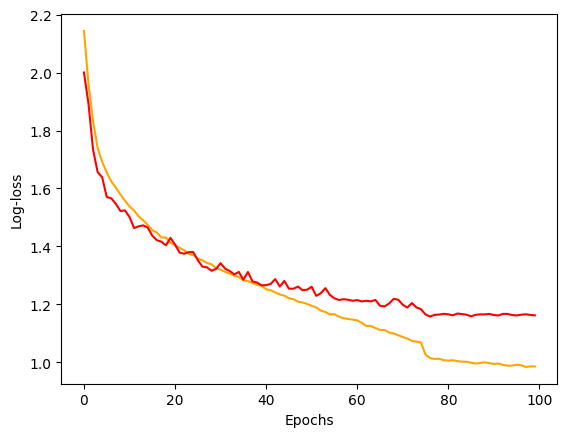

In [31]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

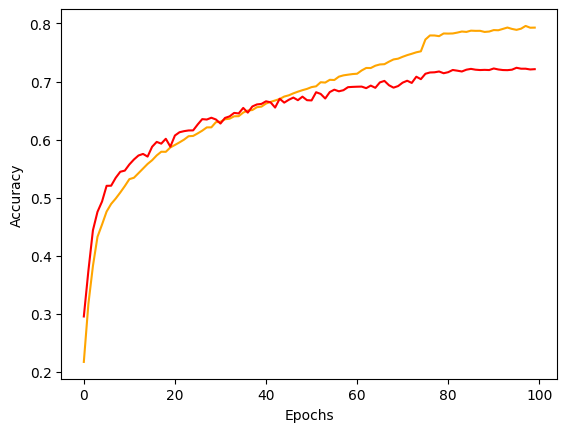

In [32]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

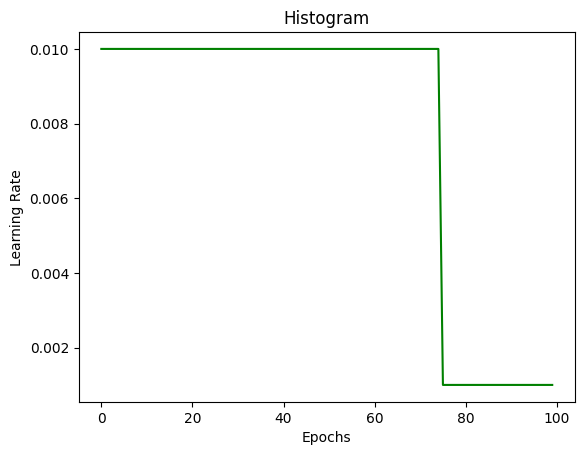

In [33]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [34]:
accu_epochs_train[99]

0.7928199768066406

In [35]:
accu_epochs_test[99]

0.7213000059127808

In [36]:
accu_epochs_test.max()

0.7236999869346619

The performance is pretty bad. Hence, one may ask why to use transformers at all. 

Well, the reason transformers trained from scratch on small datasets usually perform worse than CNNs is that, unlike CNNs, the transformer architecture has a weaker so-called *inductive bias*; a set of assumptions that the model uses to predict. As we discussed when introducing convolutions, they are ideal for detecting local translation-invariant features in an image. This property leads to a strong inductive bias, which, however, proved quite beneficial when training CNNs, since it restricts the solution space to regions where models that generalize well are found, allowing CNNs to perform well even when trained on small datasets. 

Transformers cannot rely on such a strong inductive bias; hence, they usually require more training data to perform well. But since their architecture is more expressive than that of a CNN, they can learn a better model overall, provided there is sufficient training data (the vision transformer from [[2](#2)] was trained on a dataset of 300 million images!). Our datasets do not contain millions of images, so these observations might not seem that relevant at first glance. The thing is that we are not required to train our model *from scratch* ...

### Transfer Learning <a class="anchor" id="transfer_learning"></a>

Transfer learning is a general machine learning technique in which an existing pre-trained model is reused on some new, related task. More specifically, we will consider a vision transformer trained on a large dataset and reuse it for our classification problems. 

First, we will download a trained vision transformer, *vit_l_32* (https://docs.pytorch.org/vision/main/models/vision_transformer.html), based on the original vision transformer [[2](#2)] with over 306 million parameters and it was trained from scratch on the ImageNet dataset.

In [37]:
vit_cuda = torchvision.models.vit_l_32(weights='IMAGENET1K_V1')

As we have discussed, the CIFAR-10 dataset is too small to train such a model from scratch. Hence, we will reuse the pre-trained parameter values and fix them by disabling the gradient computations for them.

In [38]:
for param in vit_cuda.parameters():
    param.requires_grad = False

Next, let us have a look at the architecture.

In [39]:
vit_cuda

VisionTransformer(
  (conv_proj): Conv2d(3, 1024, kernel_size=(32, 32), stride=(32, 32))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=1024, out_features=1024, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=1024, out_features=4096, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=4096, out_features=1024, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
       

We notice that the classification itself is performed by the linear layer *vit_cuda.heads*. We will replace this layer with a new linear layer (we need to reduce the number of outputs from 1000 to 10, since CIFAR-10 has only ten categories).

In [40]:
vit_cuda.heads = nn.Linear(1024,10)

The goal of the training will now be to learn the new linear layer while keeping the rest of the model unchanged. Our hope is that the features the model extracts, learned from training on the ImageNet dataset, will also be applicable to CIFAR-10. We just need to upscale the CIFAR-10 images to 224x224, which matches the ImageNet sizes.

In [41]:
torch.manual_seed(123)

transforms_cifar10_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size=[224,224], scale = [0.8, 1.4]),
    ]
)

transforms_cifar10_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]),
    torchvision.transforms.Resize([224,224])
    ]
)

cifar10_train = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_cifar10_train)
cifar10_test = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_cifar10_test)


cifar10_train_loader = DataLoader(dataset = cifar10_train, batch_size = 250, shuffle = True) 
cifar10_test_loader = DataLoader(dataset = cifar10_test, batch_size = 250, shuffle = False)

In [42]:
for batch, (X, y) in enumerate(cifar10_train_loader):
    break

vit_cuda = vit_cuda.to(cuda_device)
vit_cuda(X.to(cuda_device))

tensor([[-0.2716, -0.0936,  0.0979,  ..., -0.1869, -0.1282, -0.0609],
        [ 0.3379, -0.0136, -0.1717,  ..., -0.3619, -0.2239,  0.3161],
        [-0.1414,  0.3536,  0.4721,  ...,  0.1698,  0.4287,  0.3766],
        ...,
        [ 0.4158, -0.0492,  0.0998,  ...,  0.3537, -0.0296, -0.4493],
        [-0.5459, -0.4000, -0.0214,  ...,  0.1620, -0.2611,  0.5390],
        [ 0.1777,  0.2172,  0.3870,  ...,  0.2740, -0.3014, -0.2025]],
       device='cuda:0', grad_fn=<AddmmBackward0>)

In [43]:
vit_cuda(X.to(cuda_device)).size()

torch.Size([250, 10])

Let us retrain the linear layer of the pre-trained transformer.

In [44]:
n_epochs = 50

optim_SGD_cuda =  torch.optim.SGD(vit_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.0001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[35], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(cifar10_train_loader, cifar10_test_loader, vit_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

5314.464061737061


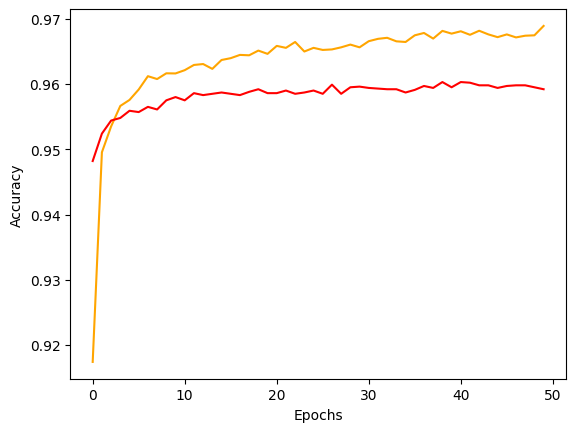

In [45]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

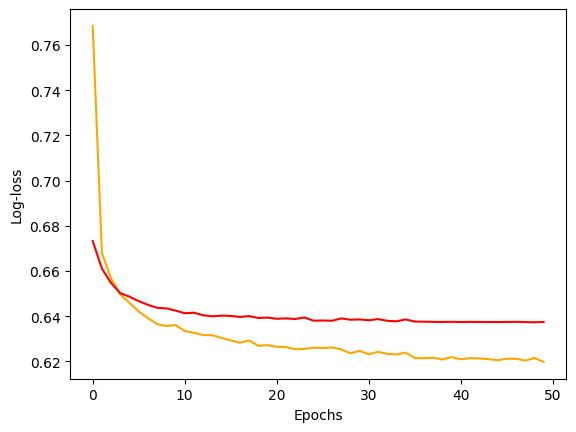

In [46]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

In [48]:
accu_epochs_train[49]

0.9688999652862549

In [49]:
accu_epochs_test[49]

0.9591999650001526

In [47]:
accu_epochs_test.max()

0.9602999687194824

Even without much tuning of learning parameters, we have achieved very good performance, surpassing all the CNN models we trained in previous projects.

## References <a class="anchor" id="references"></a>

<a id="1">[1]</a> VASWANI, Ashish, et al. Attention is all you need. *Advances in neural information processing systems*, 2017, 30.

<a id="2">[2]</a> DOSOVITSKIY, Alexey, et al. An image is worth 16x16 words: Transformers for image recognition at scale. arXiv preprint arXiv:2010.11929, 2020.

<a id="3">[3]</a> XIAO, Han; RASUL, Kashif; VOLLGRAF, Roland. Fashion-mnist: a novel image dataset for benchmarking machine learning algorithms. arXiv preprint arXiv:1708.07747, 2017.

<a id="4">[4]</a> ZHANG, Aston, et al. *Dive into deep learning*. Cambridge University Press, 2023.




<a id="2">[2]</a> BAHDANAU, Dzmitry; CHO, Kyunghyun; BENGIO, Yoshua. Neural machine translation by jointly learning to align and translate. *arXiv preprint arXiv:1409.0473*, 2014.

